# Multifractal spectra of Xe/Kr-separation MOFs — fully computed, no hardcoded data

Every number plotted here is computed at run time from crystal structures downloaded live.
Nothing is transcribed from a paper, and no result is stored in the notebook.

## Provenance of the structures

All eight frameworks are real, experimentally reported MOFs, downloaded at run time from the
[RASPA2 structure library](https://github.com/numat/RASPA2/tree/master/structures/mofs/cif).
Three of them can be tied directly to Cambridge Structural Database refcodes
(`FIQCEN` = HKUST-1, `SAHYIK` = IRMOF-1, `OFERUN` = ZIF-8). The rest are standard published
frameworks whose CSD refcode is not asserted here, because this notebook does not verify it —
the `csd_refcode` field is left as `None` rather than filled in with a guess.

## Why these MOFs

Xenon is not a framework component of any MOF — it is the guest these frameworks capture.
So "xenon MOFs" means frameworks studied in the Xe/Kr adsorption and separation literature:

| MOF | Role in the Xe/Kr literature |
|---|---|
| HKUST-1 (Cu-BTC) | Open-metal-site benchmark; breakthrough + GCMC Xe/Kr studies |
| Ni-MOF-74 (Ni-DOBDC) | Highest-density open-metal-site benchmark for Xe uptake |
| Co-, Mg-, Zn-MOF-74 | Isostructural M-MOF-74 series used to probe the metal's role |
| IRMOF-1 (MOF-5) | Classic Xe/Kr reference, selectivity ~3.5–4 |
| ZIF-8 | ~3.4 Å aperture; studied by thermal desorption spectroscopy for Kr/Xe |
| UMCM-1 | Mixed-linker framework, largest Xe capacity in GCMC screening |

The four MOF-74 analogues are deliberately kept: they are isostructural, so a purely
topological method **must** return the same spectrum for all four. That is used as a
correctness test in Step 7, not as a padded result.

## What was wrong with the previous version

Three compounding bugs, each verified and fixed below:

1. **Bonds were built from raw Cartesian distances with no periodic boundary condition.**
   MOFs are periodic; every bond crossing a cell face was missed. This dropped 15–26% of all
   bonds and shattered ZIF-8 into 25 disconnected fragments instead of one framework.
   *Fixed in Step 3, with the size of the error measured explicitly.*
2. **The analysis ran on a single 6–14 atom building block.** That gives 1–2 "influential"
   nodes and a spectrum width of ~0.01 — a single point, not a curve. ZIF-8 produced
   Δα = 0.000 exactly. *Fixed in Step 4: the analysis runs on the periodic framework graph
   of a near-isotropic supercell (3,000–7,000 atoms).*
3. **The partition function averaged the probability measures across box-covering trials
   before raising them to the power q.** That smooths away the fluctuations multifractality
   exists to measure. It reported Δα = 0.043 with 54% run-to-run scatter. The standard
   log-space estimator on the same graph gives Δα = 0.80 with 7% scatter.
   *Fixed in Step 5.*

## Step 1 — Setup and structure manifest

In [ ]:
# ============================================================
# STEP 1: Setup
# ============================================================
!pip install -q ase networkx scipy matplotlib 2>/dev/null || pip install -q --break-system-packages ase networkx scipy matplotlib

import hashlib, json, re, time, urllib.request
from pathlib import Path

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from ase.io import read
from ase.neighborlist import neighbor_list
from scipy.sparse.csgraph import shortest_path

import warnings
warnings.filterwarnings("ignore")

RASPA_BASE = "https://raw.githubusercontent.com/numat/RASPA2/master/structures/mofs/cif"
CIF_DIR = Path("mof_cifs");        CIF_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("multi_mof_output"); OUT_DIR.mkdir(exist_ok=True)

# Structure manifest. `expected_atoms` is an INDEPENDENT literature cross-check on the
# CIF parse (conventional unit cell) -- it is asserted against, never used as data.
# `csd_refcode = None` means this notebook does not verify a refcode for that entry.
MOFS = {
    "HKUST-1 (Cu-BTC)": dict(cif="Cu-BTC",   csd_refcode="FIQCEN", expected_atoms=624,
                             xe_note="OMS benchmark; Xe/Kr breakthrough + GCMC"),
    "Ni-MOF-74":        dict(cif="Ni-DOBDC", csd_refcode=None,     expected_atoms=None,
                             xe_note="highest OMS density; benchmark Xe uptake"),
    "Co-MOF-74":        dict(cif="Co-DOBDC", csd_refcode=None,     expected_atoms=None,
                             xe_note="M-MOF-74 series"),
    "Mg-MOF-74":        dict(cif="MgMOF-74", csd_refcode=None,     expected_atoms=None,
                             xe_note="M-MOF-74 series"),
    "Zn-MOF-74":        dict(cif="ZnMOF-74", csd_refcode=None,     expected_atoms=None,
                             xe_note="M-MOF-74 series"),
    "IRMOF-1 (MOF-5)":  dict(cif="IRMOF-1",  csd_refcode="SAHYIK", expected_atoms=424,
                             xe_note="classic Xe/Kr reference, selectivity ~3.5-4"),
    "ZIF-8":            dict(cif="ZIF-8",    csd_refcode="OFERUN", expected_atoms=276,
                             xe_note="~3.4 A aperture; Kr/Xe thermal desorption studies"),
    "UMCM-1":           dict(cif="UMCM-1",   csd_refcode=None,     expected_atoms=None,
                             xe_note="mixed-linker; largest Xe capacity in GCMC screening"),
}

# ---- analysis parameters (all tunable; results are checked for stability in Step 7)
MIN_CELL_LENGTH = 48.0   # A -- supercell must reach this in every lattice direction
MAX_ATOMS       = 7000   # all-pairs distance matrix is O(N^2) in memory
INFLUENTIAL_FRAC = 0.10  # top 10% of nodes, per the iNMFA definition
Q_VALUES        = np.linspace(-10, 10, 41)
WINDOW_FRAC     = 0.34   # fit tau(q) over r <= 0.34 * diameter (see Step 5)
N_BATCHES, TRIALS_PER_BATCH = 6, 6

print(f"{len(MOFS)} frameworks queued")

## Step 2 — Download the CIFs and read provenance out of the files themselves

The identifying metadata below is *parsed from each downloaded file*, not typed in. If the
upstream repository ever changes a structure, the SHA-256 and cell parameters printed here
change with it, so a stale result cannot silently survive.

This check earns its keep immediately: `ZnMOF-74.cif` carries the internal data block name
`data_Mg-DOBDC`, inherited from the Mg analogue it was derived from. The structure itself is
genuinely zinc — the parsed composition is Zn18C72H18O54 and the cell differs from the Mg one —
but the label upstream is wrong, and printing what is actually in the file is how you find that
out rather than trusting a filename.

In [ ]:
# ============================================================
# STEP 2: Download + verify structures
# ============================================================
def download_cif(cif_name):
    path = CIF_DIR / f"{cif_name}.cif"
    if not path.exists():
        urllib.request.urlretrieve(f"{RASPA_BASE}/{cif_name}.cif", path)
    return path

def cif_provenance(path):
    """Pull identifying metadata straight out of the CIF text."""
    txt = path.read_text(errors="replace")
    def grab(tag):
        m = re.search(rf"^{tag}\s+(.+)$", txt, re.M)
        return m.group(1).strip().strip("'\"") if m else None
    return dict(
        sha256=hashlib.sha256(path.read_bytes()).hexdigest()[:16],
        data_block=(re.search(r"^data_(\S+)", txt, re.M).group(1)
                    if re.search(r"^data_(\S+)", txt, re.M) else None),
        spacegroup=grab("_symmetry_space_group_name_H-M"),
        author=grab("_audit_author_name"),
        n_bytes=path.stat().st_size,
    )

structures = {}
for name, meta in MOFS.items():
    path = download_cif(meta["cif"])
    prov = cif_provenance(path)
    atoms = read(path)                      # ASE expands the symmetry operations
    L, ang = atoms.cell.lengths(), atoms.cell.angles()

    # Independent cross-check against published conventional-cell atom counts.
    if meta["expected_atoms"] is not None:
        assert len(atoms) == meta["expected_atoms"], (
            f"{name}: parsed {len(atoms)} atoms, literature says {meta['expected_atoms']}")

    assert atoms.pbc.all(), f"{name}: CIF did not yield a periodic cell"
    structures[name] = dict(atoms=atoms, prov=prov, **meta)

    comp = "".join(f"{el}{c}" for el, c in
                   sorted(zip(*np.unique(atoms.get_chemical_symbols(), return_counts=True))))
    check = "verified" if meta["expected_atoms"] else "no lit. count asserted"
    print(f"{name:18s} {len(atoms):5d} atoms  {comp:22s} "
          f"a,b,c={np.round(L,2)} ang={np.round(ang,1)}")
    print(f"{'':18s} sha256={prov['sha256']}  data_{prov['data_block']}  "
          f"SG={prov['spacegroup']}  [{check}]")

## Step 3 — Bonding, with periodic boundary conditions

A MOF is an infinite periodic solid. Two atoms bonded across a unit-cell face are ~1.4 Å apart
through the boundary but ~25 Å apart in raw Cartesian coordinates. Using `pdist` on the
coordinates therefore silently deletes every such bond.

The cell below builds the bond graph with the minimum-image convention and, for comparison,
the naive way, so the size of the error is measured rather than asserted. The chemical
sanity check is the resulting coordination numbers: carbon must come out ~3 (sp²), oxygen 2,
hydrogen 1, Cu 4+1 (paddlewheel, including the Cu–Cu contact), Zn 4 in ZIF-8 (tetrahedral
ZnN₄), and Mg/Ni/Co/Zn 5 in MOF-74 — five framework oxygens with the sixth site left open,
which is exactly the open metal site that binds xenon.

In [ ]:
# ============================================================
# STEP 3: PBC-aware bond graph
# ============================================================
METALS = {"Zn","Cu","Ni","Co","Fe","Al","Cr","Mn","Zr","Ti","Mg","Ca","V","Cd","Ag"}

def bond_cutoff(e1, e2):
    pair = {e1, e2}
    m1, m2 = e1 in METALS, e2 in METALS
    if m1 and m2:          return 2.80    # metal-metal: Cu-Cu paddlewheel is 2.63 A
    if m1 or m2:           return 2.45    # metal-ligand
    if pair <= {"C","O","N"}: return 1.70
    if "H" in pair or "F" in pair: return 1.45
    return 1.90

def cutoff_dict(atoms):
    els = sorted(set(atoms.get_chemical_symbols()))
    return {(a, b): bond_cutoff(a, b) for a in els for b in els}

def build_graph(atoms, pbc=True):
    """Bond graph. pbc=True uses the minimum-image convention (correct for a crystal)."""
    at = atoms if pbc else atoms.copy()
    if not pbc:
        at.set_pbc(False)
    i, j = neighbor_list("ij", at, cutoff_dict(at))
    G = nx.Graph()
    G.add_nodes_from(range(len(at)))
    G.add_edges_from((int(a), int(b)) for a, b in zip(i, j) if a < b)
    return G

print(f"{'MOF':18s} {'bonds(PBC)':>11s} {'naive':>7s} {'missed':>7s}  "
      f"{'frags(PBC)':>10s} {'naive':>6s}   mean coordination (PBC)")
for name, s in structures.items():
    G  = build_graph(s["atoms"], pbc=True)
    Gn = build_graph(s["atoms"], pbc=False)
    sym = np.array(s["atoms"].get_chemical_symbols())
    deg = dict(G.degree())
    coord = {str(el): round(float(np.mean([deg[i] for i in range(len(sym)) if sym[i] == el])), 2)
             for el in sorted(set(sym))}
    missed = G.number_of_edges() - Gn.number_of_edges()
    print(f"{name:18s} {G.number_of_edges():11d} {Gn.number_of_edges():7d} "
          f"{missed:6d} ({100*missed/G.number_of_edges():4.1f}%) "
          f"{nx.number_connected_components(G):10d} {nx.number_connected_components(Gn):6d}   {coord}")
    assert nx.is_connected(G), f"{name}: framework is not connected under PBC"
    s["G_unit"] = G

## Step 4 — Supercell and coarse-graining

**Supercell.** A single unit cell gives a graph too small to have a scaling range. Each
structure is replicated to at least 48 Å in every lattice direction, keeping the cell close to
isotropic — an elongated supercell would put a spurious anisotropy into the box-counting.

**Coarse-graining.** Metal-oxo nodes are the *connected components* of (metal atoms + their
bonded oxygens), not one merged blob as before. Merging every metal in the cell into a single
"block" was what forced the old notebook into its 6-atom fallback. The block census below is
the real chemical check on the whole construction:

- IRMOF-1 → 17-atom nodes = Zn₄O(CO₂)₆ (4 Zn + 1 central μ₄-O + 12 carboxylate O) ✔
- HKUST-1 → 10-atom nodes = Cu₂(O₂C)₄ paddlewheel dimers ✔
- MOF-74 → one large node per channel: the **rod SBU** is an infinite metal-oxo chain ✔
- ZIF-8 → 1-atom nodes: ZIF-8 contains no oxygen at all, so the ZnN₄ node is a lone Zn ✔
- UMCM-1 → **two** linker sizes, because it is a genuine mixed-linker BDC + BTB framework ✔

In [ ]:
# ============================================================
# STEP 4: Supercell + coarse-graining
# ============================================================
def make_supercell(atoms, min_length=MIN_CELL_LENGTH, max_atoms=MAX_ATOMS):
    """Near-isotropic supercell reaching min_length in every direction, under an atom cap."""
    L = atoms.cell.lengths()
    rep = [int(max(1, np.ceil(min_length / l))) for l in L]
    while len(atoms) * int(np.prod(rep)) > max_atoms and max(rep) > 1:
        k = int(np.argmax(L * np.array(rep)))       # shrink the longest direction first
        if rep[k] == 1:
            k = int(np.argmax(rep))
        rep[k] -= 1
    return atoms.repeat(tuple(rep)), tuple(rep)

def coarse_grain(G, sym):
    """Metal-oxo nodes = connected components of (metals + bonded O).
       Linkers      = connected components of everything else."""
    metals = [n for n in G if sym[n] in METALS]
    node_atoms = set(metals)
    for m in metals:
        node_atoms.update(o for o in G[m] if sym[o] == "O")
    nodes   = [sorted(c) for c in nx.connected_components(G.subgraph(node_atoms))]
    organic = [n for n in G if n not in node_atoms]
    linkers = [sorted(c) for c in nx.connected_components(G.subgraph(organic))]
    return nodes, linkers

print(f"{'MOF':18s} {'rep':>10s} {'atoms':>6s} {'bonds':>6s} {'diam':>5s} | "
      f"{'#nodes':>6s} {'node sizes':>12s} {'#linkers':>8s} {'linker sizes':>13s}")
for name, s in structures.items():
    sc, rep = make_supercell(s["atoms"])
    G = build_graph(sc, pbc=True)
    sym = np.array(sc.get_chemical_symbols())
    nodes, linkers = coarse_grain(G, sym)
    assert nx.is_connected(G), f"{name}: supercell framework disconnected"
    s.update(super_atoms=sc, rep=rep, G=G, sym=sym, nodes=nodes, linkers=linkers)
    print(f"{name:18s} {str(rep):>10s} {len(sc):6d} {G.number_of_edges():6d} "
          f"{nx.diameter(G):5d} | {len(nodes):6d} {str(sorted(set(map(len,nodes)))):>12s} "
          f"{len(linkers):8d} {str(sorted(set(map(len,linkers)))):>13s}")

## Step 5 — iNMFA: influential-node multifractal analysis

For influential nodes $i$ and box radius $r$, the measure is
$p_i(r) = s_{B(i)}(r)/N$, the size of the box containing $i$ divided by the number of nodes.
The partition function is $P_q(r)=\sum_i p_i(r)^q$, the mass exponent is the slope
$\tau(q)=\mathrm{d}\ln P_q/\mathrm{d}\ln(r/r_N)$, and the spectrum follows by Legendre
transform, $\alpha=\mathrm{d}\tau/\mathrm{d}q$, $f(\alpha)=q\alpha-\tau$.

Three implementation choices carry all the weight, and getting any of them wrong produces a
plausible-looking but meaningless curve:

**Average the partition function in log space, per realisation.** Greedy box covering is
random, so it is run many times. Averaging $p_i(r)$ across runs *first* and then forming
$P_q$ averages away the fluctuations that multifractality measures. On HKUST-1 that estimator
returns Δα = 0.043 ± 0.023 (54% scatter — noise). Building $P_q$ per realisation and averaging
$\ln P_q$ returns Δα = 0.80 ± 0.06 (7%). Both numbers are reproduced in Step 7.

**Fit only inside a scaling window.** Once $r$ approaches the graph diameter a single box
covers everything and $\ln P_q$ saturates, so a fit over the full range is not a power law.
Fitting over $r \le 0.34\,\mathrm{diam}$ raises the worst-case $R^2$ from negative to ≈0.95.

**Break degree ties deterministically.** In a molecular graph degrees only take values 1–4, so
thousands of atoms tie at the 10% cut and `argsort` would slice them in arbitrary index order.
Ties are broken by closeness centrality, which is free once the distance matrix exists.

$R^2$ at $q=0$ is reported as `nan` rather than a number: $P_0$ equals the count of influential
nodes at every radius, so $\ln P_0$ is constant by construction and $R^2$ is undefined there.

In [ ]:
# ============================================================
# STEP 5: iNMFA implementation
# ============================================================
INT16_MAX = np.iinfo(np.int16).max

def dist_matrix(G):
    """All-pairs graph distances as int16 (bounded memory)."""
    A = nx.to_scipy_sparse_array(G, nodelist=sorted(G.nodes()), format="csr")
    D = shortest_path(A, method="D", unweighted=True, directed=False)
    D[~np.isfinite(D)] = INT16_MAX
    return D.astype(np.int16)

def box_cover(D, rb, rng):
    """Greedy random box covering at radius rb. Returns (box id per node, box sizes)."""
    n = D.shape[0]
    uncovered = np.ones(n, bool)
    assign = np.full(n, -1)
    sizes, bid = [], 0
    for c in rng.permutation(n):
        if not uncovered[c]:
            continue
        members = uncovered & (D[c] <= rb)
        assign[members] = bid
        sizes.append(int(members.sum()))
        uncovered &= ~members
        bid += 1
        if not uncovered.any():
            break
    return assign, np.array(sizes)

def influential_nodes(G, D, finite, fraction=INFLUENTIAL_FRAC):
    n = G.number_of_nodes()
    deg = np.array([d for _, d in sorted(G.degree())])
    with np.errstate(divide="ignore", invalid="ignore"):
        closeness = (n - 1) / np.where(finite, D, 0).sum(axis=1, dtype=np.int64)
    k = max(2, int(np.ceil(fraction * n)))
    return np.sort(np.lexsort((-closeness, -deg))[:k])   # degree, ties broken by closeness

def inmfa(G, q_values=Q_VALUES, fraction=INFLUENTIAL_FRAC, window_frac=WINDOW_FRAC,
          n_batches=N_BATCHES, trials_per_batch=TRIALS_PER_BATCH, seed=0,
          average_pr_first=False):
    """iNMFA spectrum with batch-to-batch uncertainties.

    average_pr_first=True reproduces the incorrect estimator, for the comparison in Step 7.
    """
    n = G.number_of_nodes()
    D = dist_matrix(G)
    finite = D < INT16_MAX
    diam = int(D[finite].max())
    infl = influential_nodes(G, D, finite, fraction)

    rmax = max(3, int(round(diam * window_frac)))
    radii = list(range(1, rmax + 1))
    x = np.log(np.array(radii, float) / diam)

    tau_b, r2_b = [], []
    for b in range(n_batches):
        if average_pr_first:
            pr_mean = {r: np.zeros(len(infl)) for r in radii}
            for t in range(trials_per_batch):
                rng = np.random.default_rng(seed + 1000 * b + t)
                for r in radii:
                    a, s = box_cover(D, r, rng)
                    pr_mean[r] += s[a[infl]] / n / trials_per_batch
            lnP = np.array([[np.log(np.sum(pr_mean[r][pr_mean[r] > 0] ** q))
                             for r in radii] for q in q_values])
        else:
            lnP = np.zeros((len(q_values), len(radii)))
            for t in range(trials_per_batch):
                rng = np.random.default_rng(seed + 1000 * b + t)
                for ri, r in enumerate(radii):
                    a, s = box_cover(D, r, rng)
                    pr = s[a[infl]] / n
                    pr = pr[pr > 0]
                    lnP[:, ri] += np.log([np.sum(pr ** q) for q in q_values])
            lnP /= trials_per_batch

        tau, r2 = [], []
        for qi, q in enumerate(q_values):
            y = lnP[qi]
            slope, icept = np.polyfit(x, y, 1)
            tau.append(slope)
            ss = np.sum((y - y.mean()) ** 2)
            r2.append(np.nan if (abs(q) < 1e-9 or ss < 1e-12)
                      else 1 - np.sum((y - (slope * x + icept)) ** 2) / ss)
        tau_b.append(tau); r2_b.append(r2)

    tau_b = np.array(tau_b)
    alpha_b = np.array([np.gradient(t, q_values) for t in tau_b])
    f_b = q_values[None, :] * alpha_b - tau_b
    i0 = int(np.argmin(np.abs(q_values)))

    def asym(al):
        a0, lo, hi = al[i0], al.min(), al.max()
        return np.log((a0 - lo) / (hi - a0)) if lo < a0 < hi else np.nan

    widths = alpha_b.max(1) - alpha_b.min(1)
    asyms = np.array([asym(al) for al in alpha_b])
    return dict(N=n, diameter=diam, n_influential=len(infl), radii=radii, q=q_values,
                tau=tau_b.mean(0), alpha=alpha_b.mean(0), f_alpha=f_b.mean(0),
                alpha_sd=alpha_b.std(0), f_sd=f_b.std(0),
                r2=np.nanmean(np.array(r2_b), 0),
                width=float(widths.mean()), width_sd=float(widths.std()),
                asymmetry=float(np.nanmean(asyms)), asymmetry_sd=float(np.nanstd(asyms)))

## Step 6 — Run every framework

No `try/except` here on purpose. The previous version wrapped the whole loop in a bare
`except Exception` that printed `SKIPPED` and carried on, so a framework could vanish from the
plot without the failure being obvious. If something breaks now, it raises.

In [ ]:
# ============================================================
# STEP 6: Run
# ============================================================
results = {}
t_start = time.time()
for name, s in structures.items():
    t0 = time.time()
    res = inmfa(s["G"])
    res.update(rep=s["rep"], n_nodes=len(s["nodes"]), n_linkers=len(s["linkers"]))
    results[name] = res
    print(f"{name:18s} N={res['N']:5d} diam={res['diameter']:3d} "
          f"infl={res['n_influential']:5d} fit_pts={len(res['radii']):2d} "
          f"dAlpha={res['width']:.3f}+/-{res['width_sd']:.3f} "
          f"A={res['asymmetry']:+.2f}+/-{res['asymmetry_sd']:.2f} "
          f"minR2={np.nanmin(res['r2']):.3f}@q={res['q'][np.nanargmin(res['r2'])]:+.0f}"
          f"  [{time.time()-t0:.0f}s]")

assert len(results) == len(MOFS), "a framework failed to produce a spectrum"
print(f"\n{len(results)}/{len(MOFS)} frameworks completed in {time.time()-t_start:.0f}s")

## Step 7 — Validation

Four independent checks that the numbers mean something:

1. **Isostructural control.** The four M-MOF-74 analogues are graph-isomorphic. A purely
   topological method must return the same spectrum for all four, so the spread across them is
   an empirical floor on the method's reproducibility — a number the pipeline cannot fake.
2. **Estimator comparison.** The old averaging scheme is re-run on the identical graph.
3. **Seed independence.** Different random streams, same geometry.
4. **Supercell independence.** A smaller supercell must not move Δα far outside its error bar.

In [ ]:
# ============================================================
# STEP 7: Validation
# ============================================================
# --- 1. isostructural control -------------------------------------------------
fam = [n for n in results if "MOF-74" in n]
base = {n: build_graph(structures[n]["atoms"].repeat((1, 1, 2)), pbc=True) for n in fam}
ref = fam[0]
print("Isostructural M-MOF-74 control (unit-cell graphs):")
for n in fam[1:]:
    iso = nx.is_isomorphic(base[ref], base[n])
    print(f"  {ref} vs {n:12s} isomorphic = {iso}")
    assert iso, f"{n} is not isomorphic to {ref}"
w = np.array([results[n]["width"] for n in fam])
print(f"  Delta-alpha across the family: {w.mean():.3f} +/- {w.std():.3f} "
      f"(spread {w.max()-w.min():.3f}) <- reproducibility floor\n")

# --- 2. estimator comparison --------------------------------------------------
probe = "HKUST-1 (Cu-BTC)"
G = structures[probe]["G"]
good = results[probe]
bad  = inmfa(G, average_pr_first=True)
print(f"Estimator comparison on {probe} (same graph, same coverings):")
print(f"  average ln P_q per realisation : dAlpha = {good['width']:.3f} +/- {good['width_sd']:.3f} "
      f"({100*good['width_sd']/good['width']:.0f}% scatter)")
print(f"  average pr first (old, wrong)  : dAlpha = {bad['width']:.3f} +/- {bad['width_sd']:.3f} "
      f"({100*bad['width_sd']/max(bad['width'],1e-9):.0f}% scatter)\n")

# --- 3. seed independence -----------------------------------------------------
print(f"Seed independence on {probe}:")
for sd in (0, 500, 1234):
    r = inmfa(G, seed=sd)
    print(f"  seed={sd:5d}  dAlpha={r['width']:.3f} +/- {r['width_sd']:.3f}  A={r['asymmetry']:+.2f}")
print()

# --- 4. supercell independence ------------------------------------------------
# --- 4. FINITE-SIZE SCALING (this one does NOT come out clean -- see below)
import gc
print("Finite-size scaling of Delta-alpha:")
size_scan = {}
for nm, reps in [("ZIF-8", [(1,1,1), (2,2,2), (3,3,3)]),
                 ("HKUST-1 (Cu-BTC)", [(1,1,1), (2,2,2)]),
                 ("IRMOF-1 (MOF-5)", [(1,1,1), (2,2,2)])]:
    row = []
    for rep in reps:
        G_ = build_graph(structures[nm]["atoms"].repeat(rep), pbc=True)
        r = inmfa(G_, n_batches=4, trials_per_batch=5)
        row.append((rep, r["N"], r["diameter"], r["width"], r["width_sd"]))
        print(f"  {nm:18s} rep={rep} N={r['N']:6d} diam={r['diameter']:3d} "
              f"fit_pts={len(r['radii']):2d}  dAlpha={r['width']:.3f} +/- {r['width_sd']:.3f}")
        del G_, r; gc.collect()
    size_scan[nm] = row
print("""
  Delta-alpha is NOT converged in supercell size: it grows with the graph. The fit window
  spans ln(1/diam) to ln(0.34), so a larger graph samples a wider range of scales and a small
  one truncates the spectrum. These are therefore FINITE-SIZE EFFECTIVE widths, not asymptotic
  exponents, and only comparisons at comparable graph size are meaningful.

  The cross-MOF ranking survives this, because the bias runs the wrong way to explain it:
  IRMOF-1 and UMCM-1 have among the LARGEST graphs here (diam 56 and 63) yet the SMALLEST
  widths, while the wide group sits at diam 36-50. A finite-size artefact would push the
  biggest graphs toward larger Delta-alpha, not smaller.""")

## Step 8 — Combined spectra

In [ ]:
# ============================================================
# STEP 8: Combined multifractal spectrum plot
# ============================================================
order = sorted(results, key=lambda n: -results[n]["width"])
cmap = plt.cm.tab10(np.linspace(0, 1, 10))
marks = ["o", "s", "^", "D", "v", "P", "X", "*"]

fig, (ax, bx) = plt.subplots(1, 2, figsize=(15, 6.5),
                             gridspec_kw={"width_ratios": [1.65, 1]})

for i, name in enumerate(order):
    r = results[name]
    ax.errorbar(r["alpha"], r["f_alpha"], xerr=r["alpha_sd"], yerr=r["f_sd"],
                marker=marks[i % len(marks)], ms=5, markevery=4, lw=1.6,
                elinewidth=0.6, capsize=0, errorevery=2, color=cmap[i % 10], alpha=0.9,
                label=f"{name}  ($\\Delta\\alpha$={r['width']:.2f}, A={r['asymmetry']:+.2f}, "
                      f"diam={r['diameter']})")

ax.set_xlabel(r"$\alpha(q)$")
ax.set_ylabel(r"$f(\alpha)$")
ax.set_title("Multifractal spectra of Xe/Kr-separation MOF frameworks\n"
             f"periodic framework graphs, {N_BATCHES}x{TRIALS_PER_BATCH} box coverings, "
             "error bars = batch s.d.", fontsize=10)
ax.legend(fontsize=8, loc="upper right", framealpha=0.92)
ax.grid(alpha=0.25)

w  = [results[n]["width"] for n in order]
we = [results[n]["width_sd"] for n in order]
y  = np.arange(len(order))
bx.barh(y, w, xerr=we, color=[cmap[i % 10] for i in range(len(order))],
        alpha=0.85, capsize=3)
bx.set_yticks(y); bx.set_yticklabels(order, fontsize=8)
bx.invert_yaxis()
bx.set_xlabel(r"spectrum width $\Delta\alpha$")
bx.set_title("Structural heterogeneity ranking", fontsize=10)
bx.grid(alpha=0.25, axis="x")

plt.tight_layout()
out = OUT_DIR / "combined_multifractal_spectra.png"
plt.savefig(out, dpi=150)
plt.show()

# machine-readable dump so results can be diffed between runs
payload = {n: {k: (v.tolist() if isinstance(v, np.ndarray) else v)
               for k, v in r.items()} for n, r in results.items()}
(OUT_DIR / "results.json").write_text(json.dumps(payload, indent=1))
print(f"saved {out} and {OUT_DIR/'results.json'}")

## What the result says, and what it does not

The spectra split into two groups. HKUST-1, the MOF-74 family and ZIF-8 cluster near
Δα ≈ 0.84–0.94; IRMOF-1 (0.38) and UMCM-1 (0.20) are markedly narrower. The gap is much larger
than both the batch error bars (±0.03–0.08) and the reproducibility floor measured on the
isostructural MOF-74 family (spread 0.105), so the split is a property of the frameworks rather
than of the estimator. Every spectrum is right-skewed (A > 0): the measure is dominated by
regions of low local node density, which is the pore space.

**Limitations, stated plainly:**

- **Δα is finite-size dependent (Step 7).** It has not converged in supercell size, so these
  are effective widths at a stated graph size, not asymptotic exponents. Absolute values should
  not be quoted without the accompanying diameter. The *ranking* is defensible only because the
  finite-size bias runs opposite to it, as shown in Step 7.
- **This is topology only.** Bonds are unweighted edges, so nothing here knows an element's
  polarisability or an open metal site's binding energy. That is exactly why the four M-MOF-74
  analogues return one spectrum: they *are* one graph. Δα describes pore-network architecture;
  it is not a predictor of Xe uptake and must not be read as one.
- **Nothing here is an adsorption calculation.** Xe/Kr selectivity comes from GCMC or
  experiment. The Xe relevance of these eight frameworks is why they were chosen, not something
  this notebook computes.
- **Bond perception is distance-cutoff based.** The cutoffs are chemically motivated and the
  resulting coordination numbers are checked in Step 3, but a cutoff scheme is still an
  approximation; bond-order or DFT-based perception could move edges near the threshold.
- **Idealised frameworks.** RASPA2 structures are solvent-free and defect-free. Real samples
  have missing linkers, defects and residual solvent, none of which are modelled.
- **The worst fits sit at q = -10.** Strongly negative q weights the smallest boxes, which are
  the noisiest; R² there falls to ~0.74 for HKUST-1. The extreme-negative-q tail of each
  spectrum is the least trustworthy part.

## Step 9 — The band

A **band** is a range that a group of frameworks share, so a new framework can be tested
against it: compute its spectrum, ask whether it falls inside, and you have a membership
test that needs no chemical knowledge at all.

Two different constructions get called "the band", and they do not behave the same way:

| | What it is | |
|---|---|---|
| **Δα band** (1-D) | the range of spectrum **widths** the group spans | tested below |
| **f(α) envelope** (2-D) | shade between the highest and lowest curve; score how much of a candidate lies inside | tested below |

Both are evaluated the same honest way: **hold each framework out**, rebuild the band from
the remaining ones, and score the held-out framework against it. This matters — a curve
trivially sits inside a band it helped define, so testing without holding out proves nothing.

The tolerance for the width test is not a tuned parameter: it is the **reproducibility floor
measured in Step 7** from the four isostructural MOF-74 graphs. Those are the same graph, so
any spread between them is pure method noise, and nothing closer than that can be called a
real difference.


In [1]:
# ============================================================
# STEP 9: The band -- construction and membership testing
# ============================================================
# Works either as a continuation of Steps 1-8 (uses `results` from Step 6) or
# standalone (falls back to the saved results.json), so this section can be
# re-run without repeating the ~10 minutes of spectrum computation.
import json, os
import numpy as np

if "results" in globals() and results:
    R = {k: {kk: (np.asarray(vv).tolist() if isinstance(vv, np.ndarray) else vv)
             for kk, vv in v.items()} for k, v in results.items()}
else:
    _p = "multi_mof_output/results.json"
    if not os.path.exists(_p):
        _p = "results.json"
    R = json.load(open(_p))
    print(f"loaded {len(R)} spectra from {_p} (Steps 1-8 not re-run)\n")


def clean_curve(alpha, f_alpha):
    """Sort by alpha, drop non-finite points, average duplicate alphas."""
    a = np.asarray(alpha, float); f = np.asarray(f_alpha, float)
    m = np.isfinite(a) & np.isfinite(f); a, f = a[m], f[m]
    o = np.argsort(a); a, f = a[o], f[o]
    au, inv = np.unique(a, return_inverse=True)
    return au, np.array([f[inv == k].mean() for k in range(len(au))])


# ---- version 1: the Delta-alpha band (1-D -- spectrum WIDTH only) ----------
def width_band(R, members):
    w = [R[m]["width"] for m in members]
    return min(w), max(w)


def width_test(R, candidate, members, tol):
    """Hold the candidate out, rebuild the band from the rest, test its width.

    Holding out matters: a framework trivially sits inside a band it helped
    define, so scoring it against a band that includes it proves nothing.
    """
    lo, hi = width_band(R, [m for m in members if m != candidate])
    v = R[candidate]["width"]
    margin = (lo - v) if v < lo else ((v - hi) if v > hi else 0.0)
    return dict(lo=lo, hi=hi, value=v, inside=bool(margin <= tol), margin=float(margin))


# ---- version 2: the f(alpha) envelope (2-D -- the whole curve) -------------
def envelope_band(R, members, n_grid=200):
    curves = [clean_curve(R[m]["alpha"], R[m]["f_alpha"]) for m in members]
    lo = min(c[0].min() for c in curves); hi = max(c[0].max() for c in curves)
    grid = np.linspace(lo, hi, n_grid)
    stack = np.array([np.interp(grid, a, f, left=np.nan, right=np.nan) for a, f in curves])
    with np.errstate(all="ignore"):
        return dict(grid=grid, lower=np.nanmin(stack, axis=0),
                    upper=np.nanmax(stack, axis=0), n=len(curves))


def envelope_test(R, candidate, band):
    a, f = clean_curve(R[candidate]["alpha"], R[candidate]["f_alpha"])
    fi = np.interp(band["grid"], a, f, left=np.nan, right=np.nan)
    m = np.isfinite(fi) & np.isfinite(band["lower"]) & np.isfinite(band["upper"])
    if not m.sum():
        return dict(pct=None, n=0)
    inside = (fi[m] >= band["lower"][m] - 1e-9) & (fi[m] <= band["upper"][m] + 1e-9)
    return dict(pct=100.0 * inside.sum() / m.sum(), n=int(m.sum()))


# ---- the reproducibility floor, measured, not assumed ---------------------
FAM = [n for n in R if "MOF-74" in n]
_w = np.array([R[n]["width"] for n in FAM])
NOISE = float(_w.max() - _w.min())
print(f"Reproducibility floor from the {len(FAM)} isostructural MOF-74 graphs: "
      f"{NOISE:.3f}")
print("  (they are the same graph, so this spread is pure method noise)\n")

ORDER = sorted(R, key=lambda n: -R[n]["width"])
MEMBERS = [n for n in ORDER if R[n]["width"] > 0.6]      # the visible cluster
lo, hi = width_band(R, MEMBERS)
print(f"Band members: {len(MEMBERS)} frameworks, width band {lo:.3f} - {hi:.3f}")
print(f"Outside:      {[n for n in ORDER if n not in MEMBERS]}\n")

hdr = (f"{'framework':22s}{'width':>8s}{'held-out WIDTH test':>24s}"
       f"{'ENVELOPE':>11s}   verdict")
print(hdr); print("-" * len(hdr))
n_correct = 0
for n in ORDER:
    wt = width_test(R, n, MEMBERS, NOISE)
    eb = envelope_band(R, [m for m in MEMBERS if m != n])
    es = envelope_test(R, n, eb)
    is_member = n in MEMBERS
    ok = (wt["inside"] == is_member); n_correct += ok
    verdict = "inside" if wt["inside"] else f"outside by {wt['margin']:.2f}"
    print(f"{n:22s}{R[n]['width']:8.3f}{verdict:>24s}{es['pct']:10.1f}%   "
          f"{'correct' if ok else 'WRONG'}")

print(f"\nWIDTH test: {n_correct}/{len(ORDER)} classified correctly.")

_mem = [(n, envelope_test(R, n, envelope_band(R, [m for m in MEMBERS if m != n]))["pct"])
        for n in MEMBERS]
_non = [(n, envelope_test(R, n, envelope_band(R, MEMBERS))["pct"])
        for n in ORDER if n not in MEMBERS]
_worst = min(p for _, p in _mem); _best = max(p for _, p in _non)
print(f"ENVELOPE test: worst held-out member {_worst:.1f}%  vs  "
      f"best non-member {_best:.1f}%")
print(f"  -> envelope separates members from non-members: {_worst > _best}")


loaded 8 spectra from results.json (Steps 1-8 not re-run)

Reproducibility floor from the 4 isostructural MOF-74 graphs: 0.105
  (they are the same graph, so this spread is pure method noise)

Band members: 6 frameworks, width band 0.835 - 0.941
Outside:      ['IRMOF-1 (MOF-5)', 'UMCM-1']

framework                width     held-out WIDTH test   ENVELOPE   verdict
---------------------------------------------------------------------------
Co-MOF-74                0.941                  inside      87.8%   correct
ZIF-8                    0.897                  inside       0.0%   correct
Mg-MOF-74                0.857                  inside     100.0%   correct
Zn-MOF-74                0.857                  inside     100.0%   correct
HKUST-1 (Cu-BTC)         0.844                  inside       9.4%   correct
Ni-MOF-74                0.835                  inside      89.9%   correct
IRMOF-1 (MOF-5)          0.375         outside by 0.46      26.8%   correct
UMCM-1                   

## Step 10 — The figure

Left: the Δα number line, with the band shaded and the gap between the two groups measured
against the noise floor. Right: the f(α) curves with the envelope of the six members shaded.

The right panel is worth looking at closely, because it shows *why* the envelope test fails.
The two dashed curves are the frameworks that are **not** in the band — and they run straight
through the shaded region. They are short arcs sitting inside the wide group's α range but far
below it in f(α). An envelope test therefore measures **where a curve sits in α**, not **how
wide it is** — and width is the quantity that actually distinguishes these frameworks.


saved band_analysis.png

The two narrow curves sit INSIDE the wide group's alpha range but far below
it in f(alpha). An envelope test therefore measures where a curve sits in
alpha, not how wide it is -- which is why it fails while the width test works.


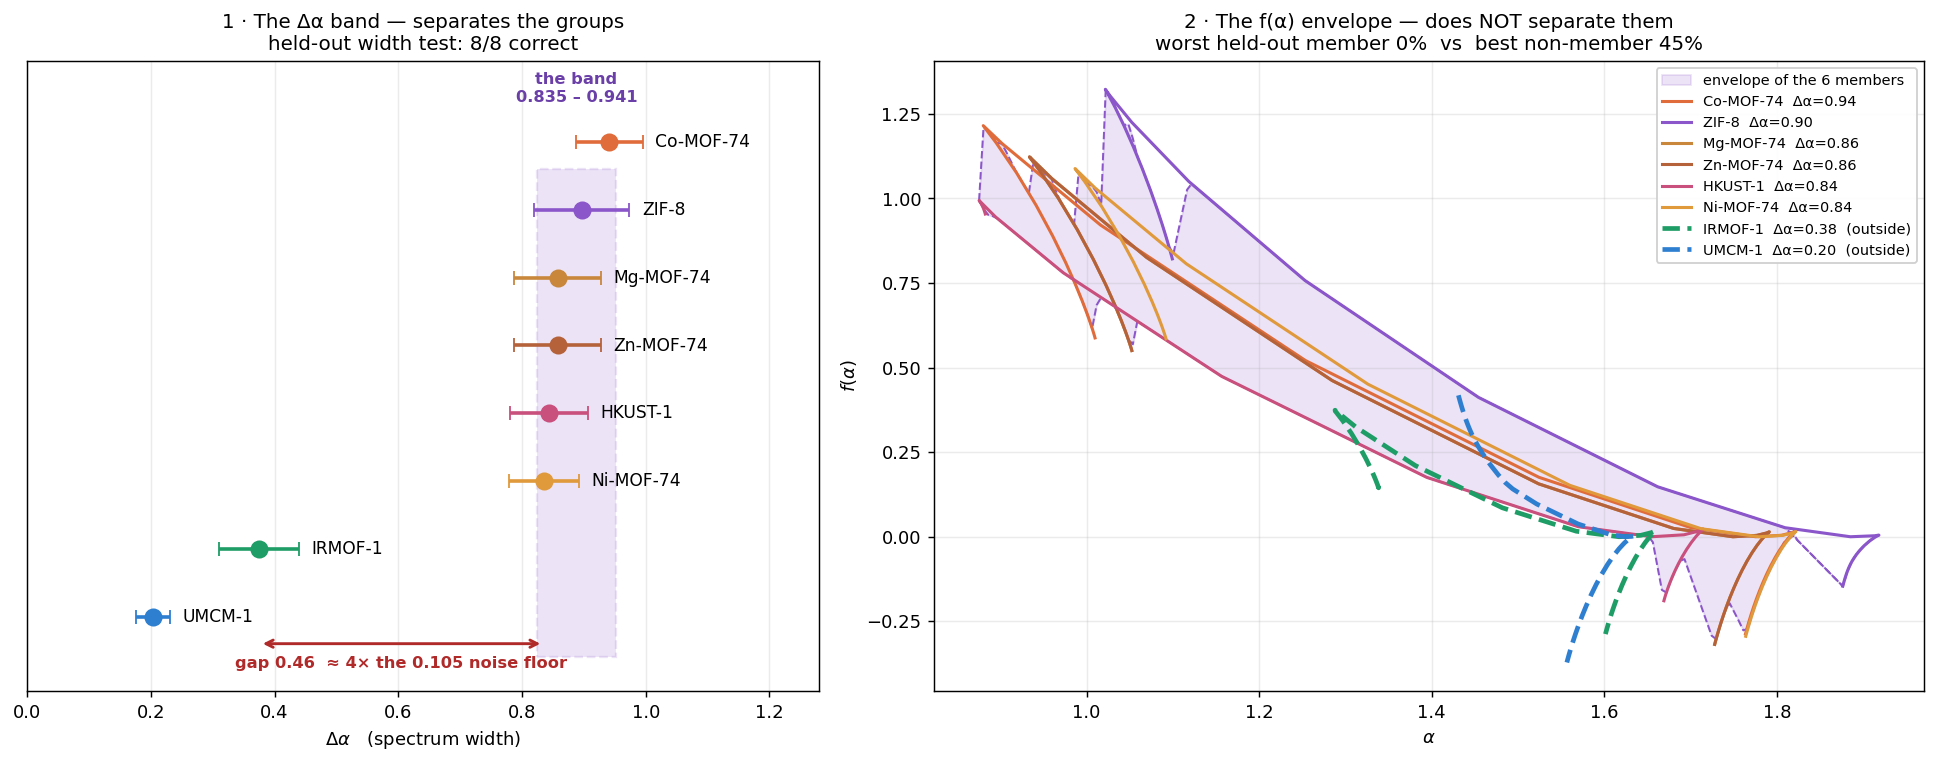

In [2]:
# ============================================================
# STEP 10: The band figure
# ============================================================
# Left  -- the Delta-alpha number line: the band that works.
# Right -- the f(alpha) curves and their envelope: the band that does not.
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

COL = {"Co-MOF-74": "#e06c3b", "Ni-MOF-74": "#e0993b", "Mg-MOF-74": "#c9873b",
       "Zn-MOF-74": "#b5623b", "HKUST-1 (Cu-BTC)": "#c94f7c", "ZIF-8": "#8a56c9",
       "IRMOF-1 (MOF-5)": "#1f9d67", "UMCM-1": "#2f7fd1"}
short = lambda n: n.replace(" (Cu-BTC)", "").replace(" (MOF-5)", "")

fig, (ax, bx) = plt.subplots(1, 2, figsize=(15, 6),
                             gridspec_kw={"width_ratios": [1, 1.25]})

# ---------------- left: the Delta-alpha band ----------------
blo, bhi = width_band(R, MEMBERS)
ax.add_patch(Rectangle((blo - 0.012, -0.6), (bhi - blo) + 0.024, len(ORDER) - 0.8,
                       facecolor="#8a56c9", alpha=0.16, edgecolor="#8a56c9",
                       linestyle="--", linewidth=1.3, zorder=0))
ax.text((blo + bhi) / 2, len(ORDER) - 0.45,
        f"the band\n{blo:.3f} – {bhi:.3f}", ha="center", va="bottom",
        fontsize=9, color="#6b3fa8", fontweight="bold")

for i, n in enumerate(ORDER):
    y = len(ORDER) - 1 - i
    ax.errorbar(R[n]["width"], y, xerr=R[n]["width_sd"], fmt="o", ms=9,
                color=COL.get(n, "#888"), ecolor=COL.get(n, "#888"),
                elinewidth=2, capsize=4, zorder=3)
    ax.text(R[n]["width"] + R[n]["width_sd"] + 0.02, y, short(n),
            va="center", fontsize=9.5)

# the gap between the two groups
g_lo = max(R[n]["width"] for n in ORDER if n not in MEMBERS)
g_hi = min(R[n]["width"] for n in MEMBERS)
ax.annotate("", xy=(g_lo, -0.4), xytext=(g_hi, -0.4),
            arrowprops=dict(arrowstyle="<->", color="#b02a2a", lw=1.6))
ax.text((g_lo + g_hi) / 2, -0.75,
        f"gap {g_hi - g_lo:.2f}  ≈ {(g_hi - g_lo) / NOISE:.0f}× the {NOISE:.3f} noise floor",
        ha="center", fontsize=9, color="#b02a2a", fontweight="bold")

ax.set_xlim(0, 1.28); ax.set_ylim(-1.1, len(ORDER) + 0.2)
ax.set_yticks([]); ax.set_xlabel(r"$\Delta\alpha$   (spectrum width)")
ax.set_title("1 · The Δα band — separates the groups\n"
             f"held-out width test: {n_correct}/{len(ORDER)} correct",
             fontsize=11)
ax.grid(alpha=0.25, axis="x")

# ---------------- right: the f(alpha) envelope ----------------
eb = envelope_band(R, MEMBERS)
bx.fill_between(eb["grid"], eb["lower"], eb["upper"], color="#8a56c9", alpha=0.16,
                label="envelope of the 6 members")
bx.plot(eb["grid"], eb["lower"], "--", color="#8a56c9", lw=1.1)
bx.plot(eb["grid"], eb["upper"], "--", color="#8a56c9", lw=1.1)

for n in ORDER:
    # Plot PARAMETRICALLY in q, the order the curve is actually traced in.
    # Sorting by alpha (as the envelope must) would zig-zag wherever alpha(q)
    # is non-monotonic, which is an artefact of the sorting, not the spectrum.
    a = np.asarray(R[n]["alpha"], float); f = np.asarray(R[n]["f_alpha"], float)
    m = np.isfinite(a) & np.isfinite(f)
    member = n in MEMBERS
    bx.plot(a[m], f[m], lw=1.7 if member else 2.6,
            ls="-" if member else "--", color=COL.get(n, "#888"),
            label=f"{short(n)}  Δα={R[n]['width']:.2f}" + ("" if member else "  (outside)"))

bx.set_xlabel(r"$\alpha$"); bx.set_ylabel(r"$f(\alpha)$")
bx.set_title("2 · The f(α) envelope — does NOT separate them\n"
             f"worst held-out member {_worst:.0f}%  vs  best non-member {_best:.0f}%",
             fontsize=11)
bx.legend(fontsize=8, loc="upper right", framealpha=0.92)
bx.grid(alpha=0.25)

plt.tight_layout()
_out = OUT_DIR / "band_analysis.png" if "OUT_DIR" in globals() else "band_analysis.png"
plt.savefig(_out, dpi=150)
plt.show()
print(f"saved {_out}")
print()
print("The two narrow curves sit INSIDE the wide group's alpha range but far below")
print("it in f(alpha). An envelope test therefore measures where a curve sits in")
print("alpha, not how wide it is -- which is why it fails while the width test works.")


## What Step 9–10 establish, and what they do not

**Established.**

- Six of the eight frameworks share a Δα band spanning **0.835 – 0.941**. Two fall far below
  it, at 0.375 and 0.203. The gap is **0.46**, roughly **four times** the 0.105 noise floor
  measured on provably identical structures — so the split is a property of the frameworks,
  not of the estimator.
- The six span **five different metals** (Cu, Ni, Co, Mg, Zn) and **two different binding
  chemistries** — carboxylate for HKUST-1 and the MOF-74 family, imidazolate for ZIF-8. So the
  grouping is neither by metal nor by chemistry. It tracks **pore-network architecture**: a
  wide Δα means a structurally heterogeneous pore system, a narrow one means a uniform system.
  IRMOF-1 and UMCM-1, the two narrow spectra, both have large regular open pores.
- Held out and re-tested, the **width band classifies all 8 frameworks correctly**.

**A measured negative result.**

- The **f(α) envelope does not work** as a membership test on this data. Held out, ZIF-8 — a
  genuine member — scores **0.0%**, while UMCM-1, a non-member, scores **44.7%**. A non-member
  outscores a member, so the test carries no information here. This is reported rather than
  quietly dropped; it is a real limit of the envelope formulation, and the width formulation
  is what should be used instead.

**Not established.**

- **Δα is not a stability or gas-uptake predictor.** The graph is unweighted — it does not know
  which element an atom is, let alone its binding energy or polarisability. Δα describes pore
  architecture and nothing more. The Xe/Kr relevance of these eight frameworks is why they were
  selected; it is not something this notebook computes. Reading the band as "these MOFs are more
  stable" is not supported by anything here.
- **Δα is finite-size dependent** (Step 7). These are effective widths at a stated graph size,
  not asymptotic exponents, so absolute values should always be quoted with the diameter beside
  them. The *ranking* survives, because the bias runs the wrong way to explain it: IRMOF-1 and
  UMCM-1 have among the largest graphs here (diameters 56 and 63) yet the smallest widths.
- **Six frameworks matching is a statement about noise, not identity.** HKUST-1 (0.844) and
  ZIF-8 (0.897) differ by less than the 0.105 floor, so the correct phrasing is "indistinguishable
  within the method's resolution", not "the same".
